In [ ]:
from AoE2ScenarioParser.datasets.players import PlayerId
from AoE2ScenarioParser.datasets.units import UnitInfo
from AoE2ScenarioParser.datasets.buildings import BuildingInfo
from AoE2ScenarioParser.datasets.other import OtherInfo
from AoE2ScenarioParser.datasets.terrains import TerrainId
from src.common.enums.enum import (
    MapLayerType,
    ObjectSize,
    GateType,
    TemplateTypes,
    ObjectRotation,
    YamlReplacementKeywords,
    CheckPlacementReturnTypes,
)

from src.scenario.scenario import Scenario
import numpy as np
import random
from src.common.constants.constants import (
    DEFAULT_EMPTY_VALUE,
    BASE_SCENE_DIR_LINUX,
    BASE_SCENARIO_NAME,
    TEMPLATE_DIR_LINUX,
)
from src.common.constants.default_objects import (
    GHOST_OBJECT_DISPLACEMENT,
    DEFAULT_EMPTY_OBJECT,
)
from src.common.enums.enum import GateType
import multiprocessing as mp
from src.map.map import Map
import os
import inspect
import ast
import json
from enum import Enum
from src.units.wallgenerators.voronoi import VoronoiGenerator
from AoE2ScenarioParser.scenarios.aoe2_de_scenario import AoE2DEScenario
from src.units.placers.statictemplate import TemplateCreator
from src.units.placers.group_placer import GroupPlacerManager
from src.map.map_object import MapObject
from src.visualizer.visualizer import Visualizer
from src.units.placers.gate_placer import GatePlacer
from src.units.placers.wall_placer import WallPlacer
from src.map.map_manager import MapManager
from src.units.placers.placer_configs import *
from src.units.placers.placer_configs import PlaceGroupsConfig
import dataclasses
import json
from src.units.wallgenerators.polygon import generate_polygonal_wall_corner_points
from src.units.placers.gate_utility import AdvancedWallPlacer

In [8]:
map_manager = MapManager(200)

In [9]:
radius = 22

In [ ]:
wall_placer = AdvancedWallPlacer()

# Create point collection for placement
point_collection = map_manager.point_manager.add_point_collection(
    "wall_points", 
    [(x, y) for x in range(200) for y in range(200)], 
    True
)

# Place walls with gates using the AdvancedWallPlacer
wall_placer.generate_polygon_walls_with_gates(
    map_manager=map_manager,
    point_collection=point_collection,
    point=(50, 50),
    sides=8,
    radius=radius,
    gate_type=GateType.PALISADE_GATE,
    player_id=PlayerId.ONE
)

wall_placer.generate_polygon_walls_with_gates(
    map_manager=map_manager,
    point_collection=point_collection,
    point=(50, 100),
    sides=8,
    radius=radius,
    gate_type=GateType.CITY_GATE,
    player_id=PlayerId.ONE
)

wall_placer.generate_polygon_walls_with_gates(
    map_manager=map_manager,
    point_collection=point_collection,
    point=(100, 100),
    sides=8,
    radius=radius,
    gate_type=GateType.FORTIFIED_GATE,
    player_id=PlayerId.ONE
)

wall_placer.generate_polygon_walls_with_gates(
    map_manager=map_manager,
    point_collection=point_collection,
    point=(100, 50),
    sides=8,
    radius=radius,
    gate_type=GateType.SEA_GATE,
    player_id=PlayerId.ONE
)

wall_placer.generate_polygon_walls_with_gates(
    map_manager=map_manager,
    point_collection=point_collection,
    point=(150, 50),
    sides=8,
    radius=radius,
    gate_type=GateType.STONE_GATE,
    player_id=PlayerId.ONE
)

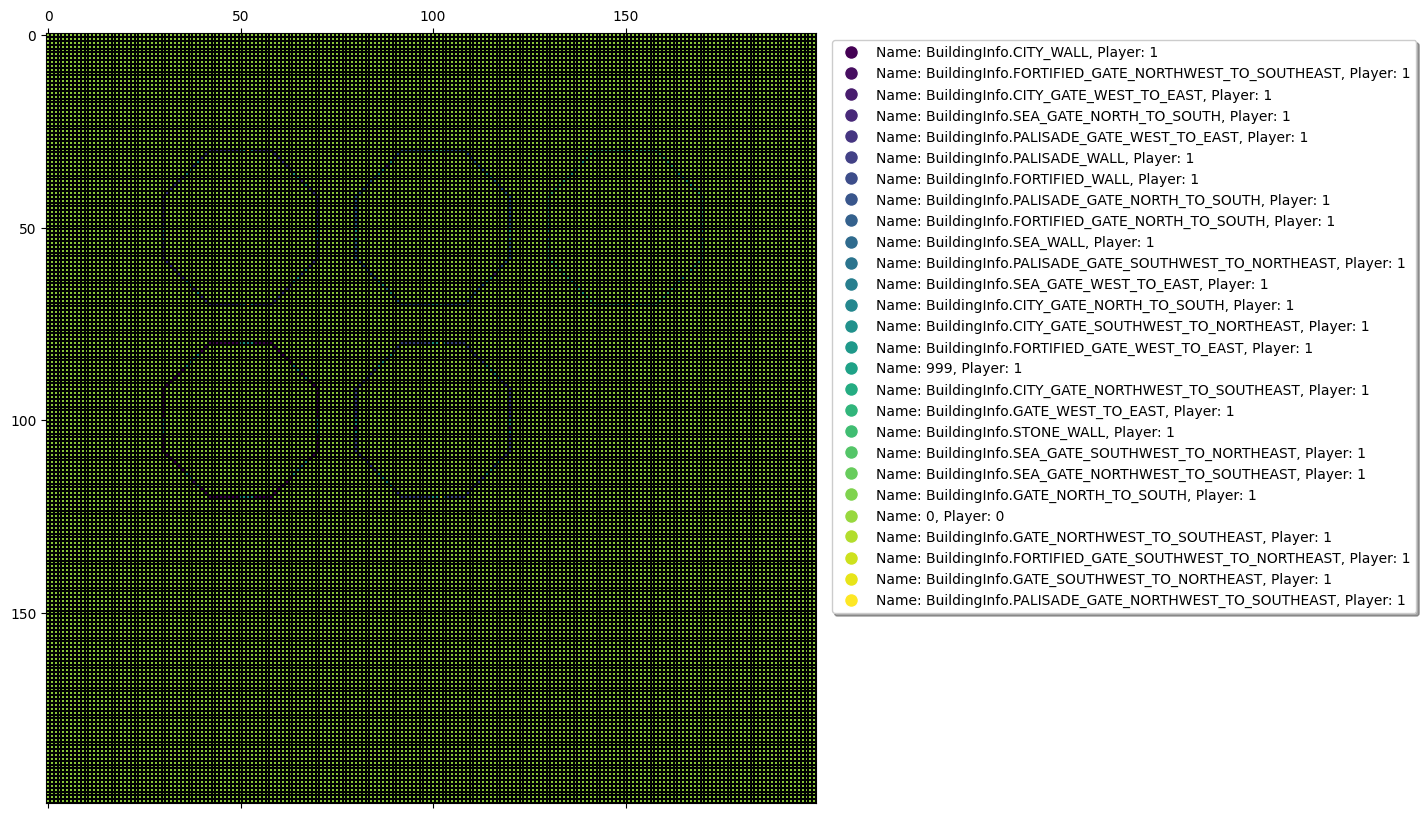

In [11]:
map_manager.visualize_map(
    VisualizeMapConfig(
        map_layer_type=MapLayerType.UNIT,
        fig_size=(10, 10),
        include_legend=True,
        transpose=True,
        anchor=(1.4, 1),
    )
)

In [6]:
scen = Scenario(aoe2_map=map_manager.get_map())
scen.write_map()
scen.save_file(os.path.join(BASE_SCENE_DIR_LINUX, "gates_test.aoe2scenario"))


[23:23:13] Reading file: '/home/joseph/.steam/steam/steamapps/compatdata/813780/pfx/dosdevices/c:/users/steamuser/Games/Age of Empires 2 DE/76561198242754748/resources/_common/scenario/BASE_SCENARIO.aoe2scenario'
[23:23:13] Reading scenario file finished successfully.

############### Attributes ###############
>>> Game version: 'DE'
>>> Scenario version: 1.53
>>> Scenario variant: 'Age of Empires 2'
##########################################

[23:23:13] Loading scenario structure finished successfully.
[23:23:13] Parsing scenario file...
	✔ FileHeadereHeader data...
	✔ DataHeaderaHeader data...
	✔ Messagesessages data...
	✔ Cinematicsematics data...
	✔ BackgroundImagendImage data...
	✔ PlayerDataTwoDataTwo data...
	✔ GlobalVictoryVictory data...
	✔ Diplomacyplomacy data...
	✔ OptionsOptions data...
	✔ Maping Map data...
	✔ Unitsg Units data...
	✔ Triggersriggers data...
	✔ Filesg Files data...
[23:23:15] Parsing scenario file finished successfully.

[23:23:15] Setting up managers ...